In [1]:
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import required libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import scipy
import sys

In [4]:
#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [5]:
#Path for the Data
if not os.path.exists("../data/development_data.csv"):
    print("Data Path does not exist. Expected in `../data/development_data.csv`")
    exit

dev_data = pd.read_csv(os.path.join("../data/development_data.csv"))


In [6]:
#Read and explore data
print(f"The dimensions of the data set is: {dev_data.shape}")
dev_data.info

The dimensions of the data set is: (456, 1004)


<bound method DataFrame.info of      sample_id  age             ethnicity sex  cg16867657  cg06639320  \
0    GSM990554   79  Caucasian - European   M    0.672001    0.504461   
1    GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214   
2    GSM990589   78  Caucasian - European   M    0.781318    0.554360   
3    GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584   
4    GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217   
..         ...  ...                   ...  ..         ...         ...   
451  GSM990042   73  Caucasian - European   F    0.701082    0.499879   
452  GSM989870   73  Caucasian - European   F    0.720217    0.685392   
453  GSM989850   84  Caucasian - European   F    0.776467    0.573109   
454  GSM989985   54  Caucasian - European   M    0.687728    0.493307   
455  GSM989963   64  Caucasian - European   F    0.701412         NaN   

     cg24724428  cg07553761  cg22454769  cg06784991  ...  cg17321954  \
0      0.331257    

In [7]:
#Get information about the type of the data
dev_data.dtypes

sample_id         str
age             int64
ethnicity         str
sex               str
cg16867657    float64
               ...   
cg12179661    float64
cg16780603    float64
cg00588614    float64
cg13039082    float64
cg16640358    float64
Length: 1004, dtype: object

In [8]:
#Get information about the names of the columns
print(dev_data.columns)

Index(['sample_id', 'age', 'ethnicity', 'sex', 'cg16867657', 'cg06639320',
       'cg24724428', 'cg07553761', 'cg22454769', 'cg06784991',
       ...
       'cg17321954', 'cg17783401', 'cg26483332', 'cg22730412', 'cg14704921',
       'cg12179661', 'cg16780603', 'cg00588614', 'cg13039082', 'cg16640358'],
      dtype='str', length=1004)


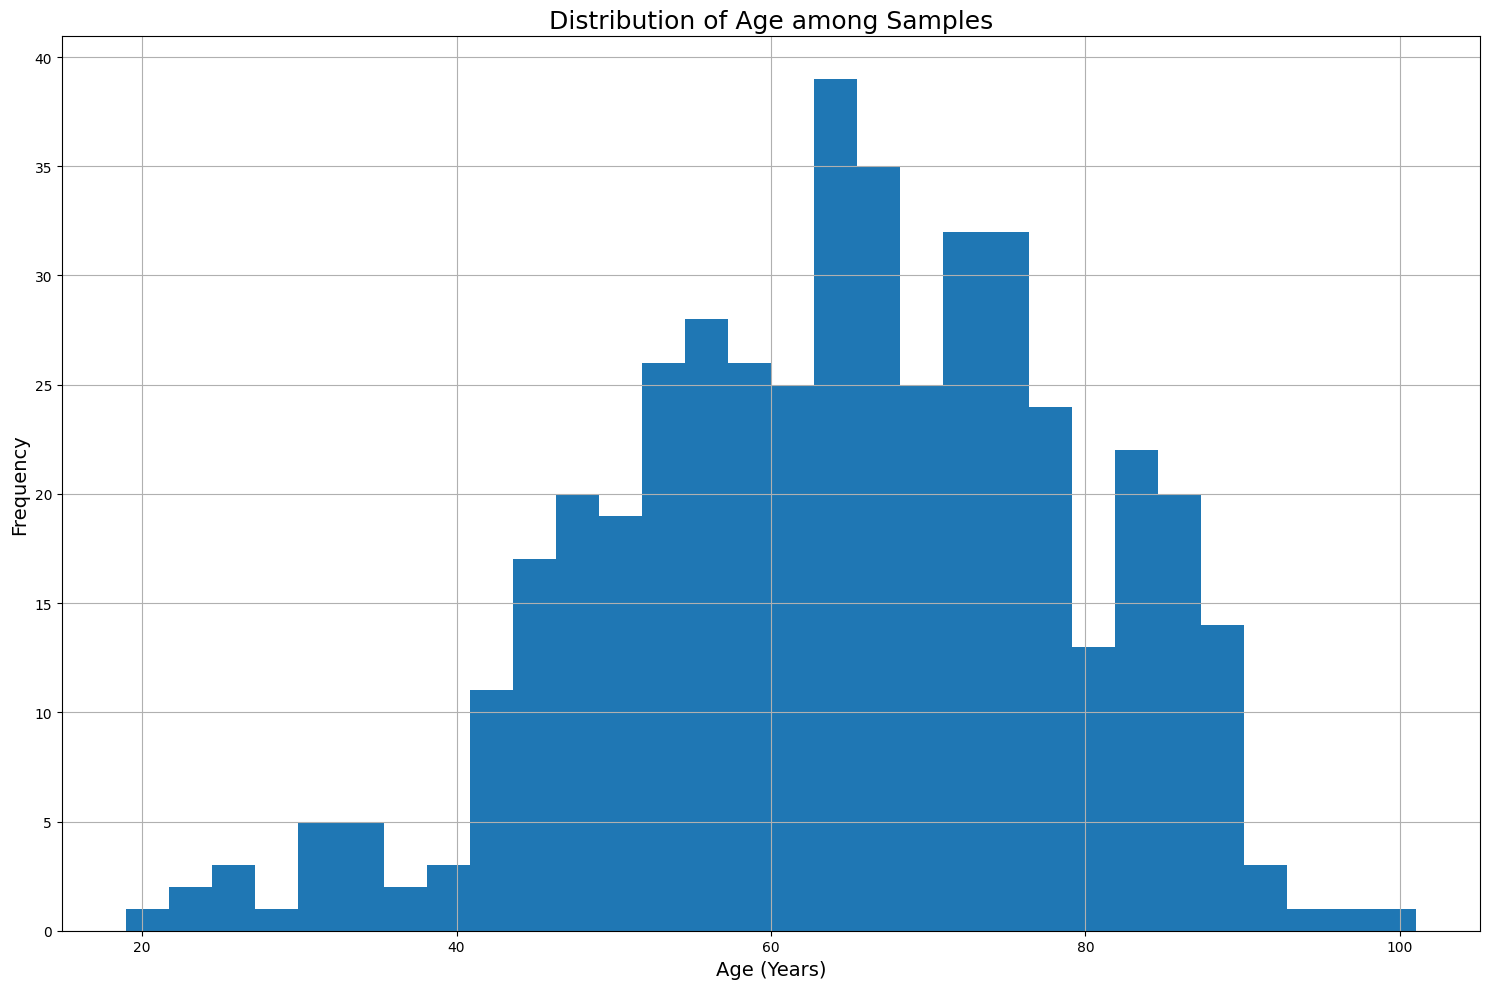

In [17]:
#Explore the distribution of the age (target variable) among my samples
#Statistics for the variables
statistics = dev_data.describe()

os.makedirs('../figures/Task1_Figures', exist_ok=True)
#Plot the distribution of age
dev_data['age'].hist(bins=30, figsize=(15,10))
plt.title('Distribution of Age among Samples', fontsize=18)
plt.xlabel('Age (Years)',fontsize=14)
plt.ylabel('Frequency',fontsize=14)
plt.tight_layout()
plt.savefig('../figures/Task1_Figures/Age_Distribution_Before_Spliting.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
#Count the representation of each age value in the dataset
age_counts = dev_data['age'].value_counts()

print(age_counts)
print(f"Ages tha appear only once: {len(age_counts[age_counts==1])}")

age
69    16
66    16
73    16
64    15
76    15
      ..
28     1
25     1
38     1
93     1
23     1
Name: count, Length: 69, dtype: int64
Ages tha appear only once: 12


In [11]:
#For the categorical variables (metadata) explore the unique values
print(dev_data['ethnicity'].unique())
print(dev_data['sex'].unique())

<StringArray>
['Caucasian - European', 'Hispanic - Mexican']
Length: 2, dtype: str
<StringArray>
['M', 'F']
Length: 2, dtype: str


In [18]:
#Clean the data before spliting
#First remove the sample_id column (no information here)
dev_df = dev_data.copy()
dev_df = dev_df.drop(columns=['sample_id'])

#Map the categorical values 
map_sex_labels = {'M': 0, 'F':1}
dev_df['sex'] = dev_df['sex'].map(map_sex_labels).astype('category')

map_ethnicity_labels = {'Caucasian - European': 0, 'Hispanic - Mexican': 1}
dev_df['ethnicity'] =dev_df['ethnicity'].map(map_ethnicity_labels).astype('category')

#Split the data using the split_data function
#From the above analysis, I can see that there are 12 age values that appear only once in the dataset
#So, I have to create age groups and then split the data. I decided to create 4 different age groups

#Import function
from src.functions import split_data

X_train, X_val, y_train, y_val = split_data(dev_df, target='age')

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Training set size: 364
Validation set size: 92


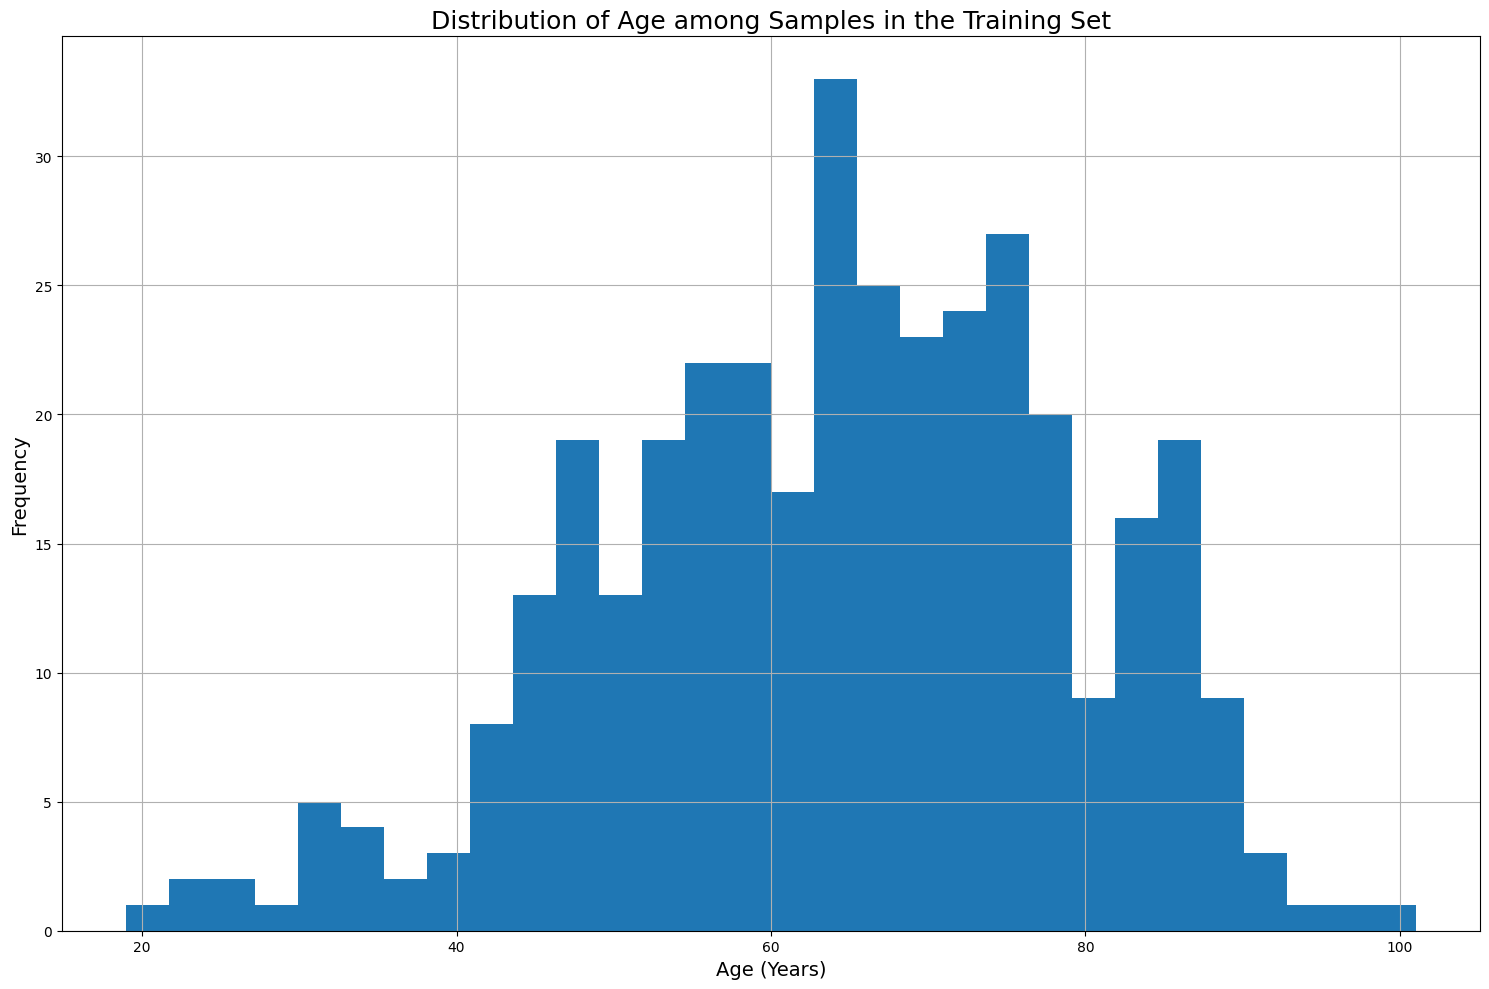

The number of samples in the Training Set is: 364
The Age mean in the Training Set is: 64.40 years with 14.88 Std
The Age range of the Training Set is: 19 - 101 years


In [20]:
#Visualize the distribution of age in the training and validation sets
os.makedirs('../figures/Task1_Figures', exist_ok=True)
#Plot the distribution of age for training set
y_train.hist(bins=30, figsize=(15,10))
plt.title(f'Distribution of Age among Samples in the Training Set', fontsize=18)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/Task1_Figures/Age_Distribution_Training_Set.png', dpi=300, bbox_inches='tight')
plt.show()

y_train_stats = y_train.describe()
y_train_stats

print(f"The number of samples in the Training Set is: {len(y_train)}")
print(f"The Age mean in the Training Set is: {(y_train).mean():.2f} years with {(y_train).std():.2f} Std")
print(f"The Age range of the Training Set is: {(y_train).min()} - {(y_train).max()} years")


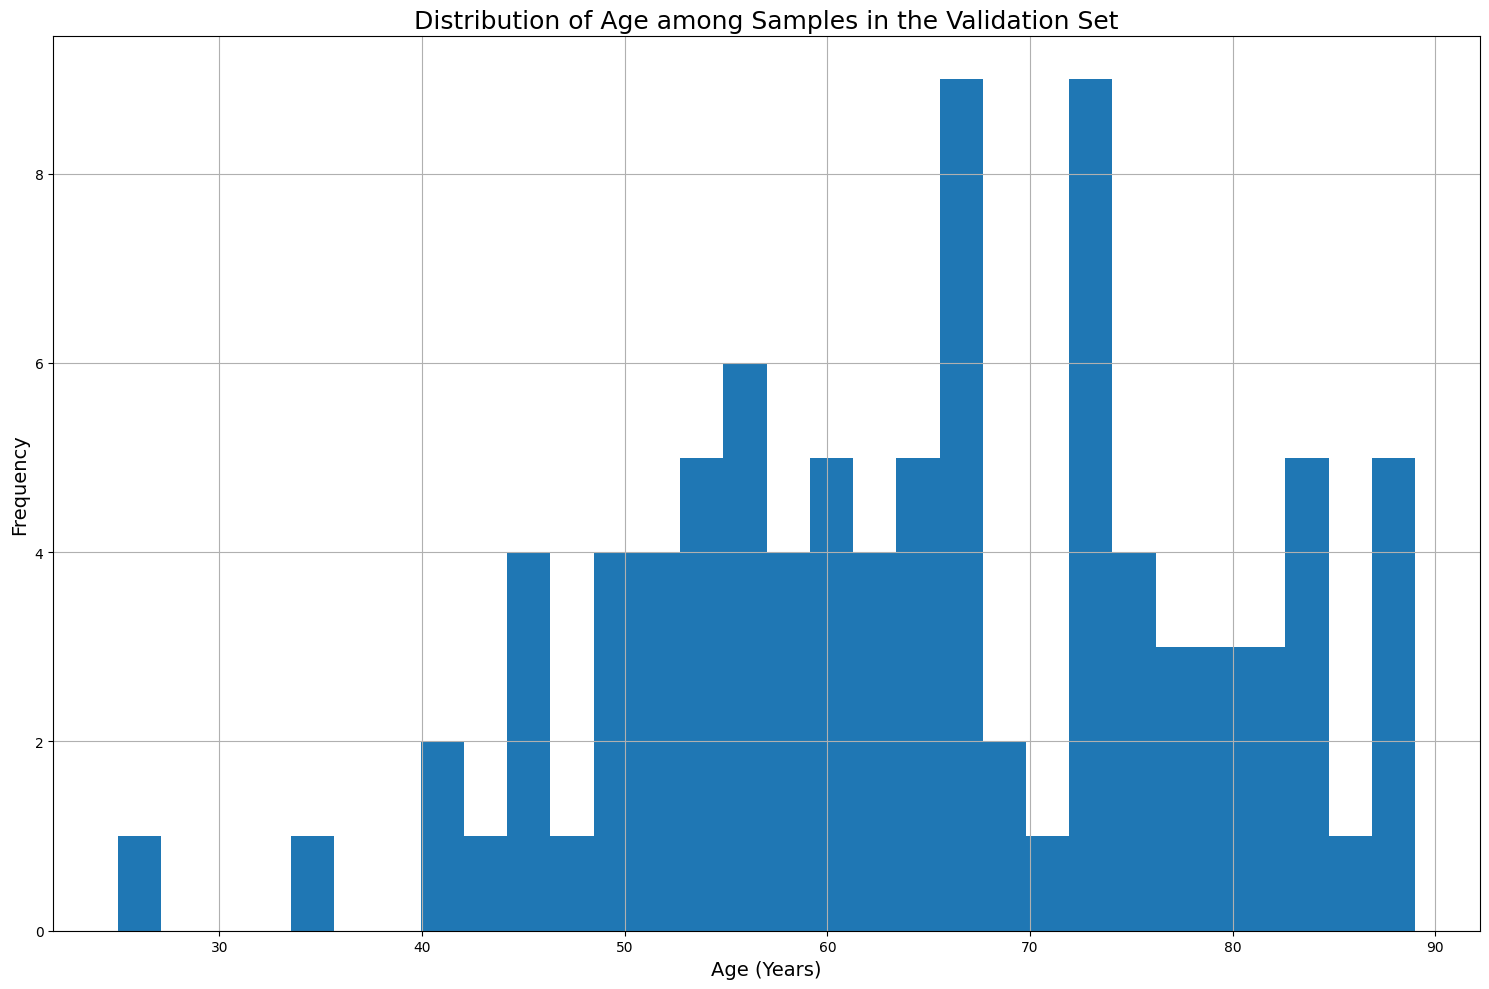

The number of samples in the Training Set is: 92
The Age mean in the Training Set is: 64.67 years with 13.66 Std
The Age range of the Training Set is: 25 - 89 years


In [21]:
#Plot the distribution of age for validation test
y_val.hist(bins=30, figsize=(15,10))
plt.title(f'Distribution of Age among Samples in the Validation Set', fontsize=18)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/Task1_Figures/Age_Distribution_Validation_Set.png', dpi=300, bbox_inches='tight')
plt.show()

y_val_stats = y_val.describe()
y_val_stats


print(f"The number of samples in the Training Set is: {len(y_val)}")
print(f"The Age mean in the Training Set is: {(y_val).mean():.2f} years with {(y_val).std():.2f} Std")
print(f"The Age range of the Training Set is: {(y_val).min()} - {(y_val).max()} years")



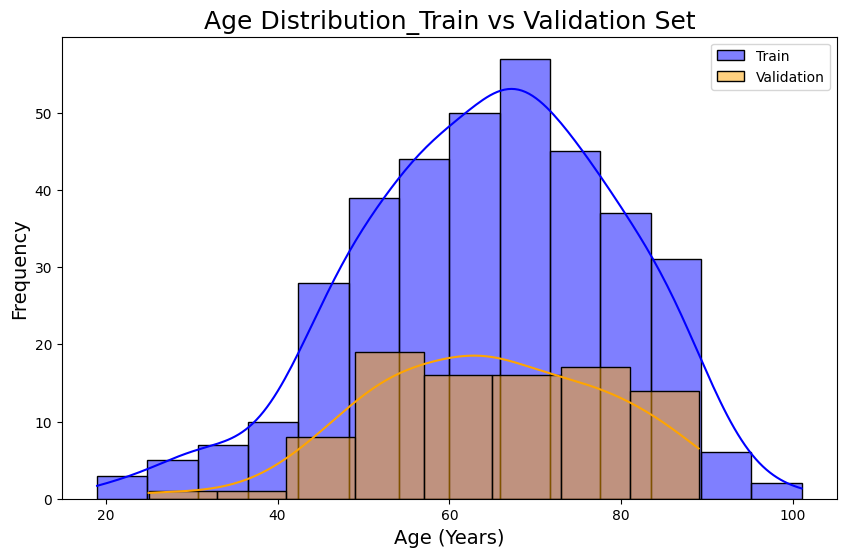

In [22]:
#Visualtization of the Age distribution in the Training Set versus the Validation set

plt.figure(figsize=(10,6))
sns.histplot(y_train, label='Train', kde=True, color='blue', alpha=0.5)
sns.histplot(y_val, label='Validation', kde=True, color='orange', alpha=0.5)
plt.title('Age Distribution_Train vs Validation Set', fontsize=18)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.savefig('../figures/Task1_Figures/Age_Distribution_Combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
#Explore the training set
#Check the existence of Na values, calculate the percentage for each column

Na_total = []
Na_thresh = {}

for column in X_train.columns:
    percentage_na = X_train[column].isna().mean() * 100
    print(f"{column} %Na : {percentage_na:.2f}%")
    Na_total.append(percentage_na)

    if percentage_na > 10:
        Na_thresh[column]=percentage_na
    

print(f"Number of columns with NA% > 10 : {len(Na_thresh)}")
print(f"Mean %Na percentage: {max(Na_total)}")

ethnicity %Na : 0.00%
sex %Na : 0.00%
cg16867657 %Na : 3.30%
cg06639320 %Na : 2.20%
cg24724428 %Na : 2.47%
cg07553761 %Na : 3.57%
cg22454769 %Na : 2.47%
cg06784991 %Na : 2.47%
cg21572722 %Na : 3.30%
cg24079702 %Na : 2.20%
cg03032497 %Na : 2.20%
cg08234504 %Na : 3.02%
cg10501210 %Na : 3.02%
cg04875128 %Na : 3.30%
cg14692377 %Na : 1.92%
cg16015712 %Na : 1.92%
cg19283806 %Na : 3.02%
cg07547549 %Na : 1.65%
cg07080372 %Na : 3.02%
cg23500537 %Na : 2.75%
cg08160331 %Na : 2.47%
cg22158769 %Na : 1.65%
cg01763090 %Na : 1.92%
cg05991454 %Na : 3.57%
cg02650266 %Na : 2.75%
cg09168222 %Na : 3.57%
cg08097417 %Na : 1.65%
cg22736354 %Na : 3.30%
cg01974375 %Na : 3.02%
cg07955995 %Na : 2.47%
cg23078123 %Na : 2.75%
cg07082267 %Na : 3.57%
cg00292135 %Na : 1.92%
cg03259243 %Na : 3.02%
cg11176990 %Na : 4.67%
cg14361627 %Na : 3.02%
cg16054275 %Na : 4.12%
cg03735592 %Na : 2.47%
cg25994988 %Na : 2.47%
cg22796704 %Na : 1.65%
cg23744638 %Na : 1.65%
cg06240854 %Na : 2.20%
cg26935102 %Na : 3.85%
cg16932827 %Na : 3.

In [26]:
#From the above, I can see that the percentage of Na values in each CpG site
#is not big, so there are not any sites that have to be excluded entirely.
#We should select a method to replace Na values.
#I think that the best way is to replace Na values with the median of the respective column.
#I think by using a ML algorith to predict the Na values will risk to add noise in my data or change the correlation between the CpG features.

#Define the numerical_features and the categorical_features
categorical_features = ['sex', 'ethnicity']
numerical_features = [columns for columns in X_train.columns if columns not in categorical_features]

#Import the preprocessing_pipeline fron the src/functions.py 
from src.functions import preprocessing_pipeline

#Apply the preprocessor
preprocessor = preprocessing_pipeline(numerical_features, categorical_features)

#Fit on training set and transform the validation set
#Fit and transform training set (learns the median from the training set)
X_train_proc = preprocessor.fit_transform(X_train)

#Transform validation set (No fitting - Data leakage)
X_val_proc = preprocessor.transform(X_val)

#Column names after preprocessor
prep_names = preprocessor.named_transformers_['categorical'].get_feature_names_out(categorical_features)
columns_final = list(numerical_features) + list(prep_names)

X_train_final = pd.DataFrame(X_train_proc, columns = columns_final, index=X_train.index)
X_val_final = pd.DataFrame(X_val_proc, columns=columns_final, index=X_val.index)

In [27]:
#Different feature matrices
metadata_cols_only = ['sex_1', 'ethnicity_1']
cpg_cols_only = [col for col in X_train_final.columns if col not in metadata_cols_only]

#For the training set
X_train_metadata = X_train_final[metadata_cols_only]
X_train_cpg = X_train_final[cpg_cols_only]

#For the validation set
X_val_metadata = X_val_final[metadata_cols_only]
X_val_cpg = X_val_final[cpg_cols_only]

#Only Metadata - sex and ethnicity (X_train_metadata)
#Only CpG values - DNA data (X_train_cpg)
#Combined Data (X_train_final)


In [28]:
#Save the feature matrices

#Create a folder inside the data folder
os.makedirs('../data/processed', exist_ok=True)

#Save the matrices for the training set
X_train_metadata.to_pickle('../data/processed/X_train_metadata.pkl')
X_train_cpg.to_pickle('../data/processed/X_train_cpg.pkl')
X_train_final.to_pickle('../data/processed/X_train_final.pkl')
y_train.to_pickle('../data/processed/y_train.pkl')

#Save the matrices for the validation set
X_val_metadata.to_pickle('../data/processed/X_val_metadata.pkl')
X_val_cpg.to_pickle('../data/processed/X_val_cpg.pkl')
X_val_final.to_pickle('../data/processed/X_val_final.pkl')
y_val.to_pickle('../data/processed/y_val.pkl')

print("Feature Matrices for Training and Validation Set saved successfully")

Feature Matrices for Training and Validation Set saved successfully


Frequency of different sexes in the Training Set: sex_1
0.0    191
1.0    173
Name: count, dtype: int64
Frequency of different sexes in the Validation Set: sex_1
1.0    51
0.0    41
Name: count, dtype: int64


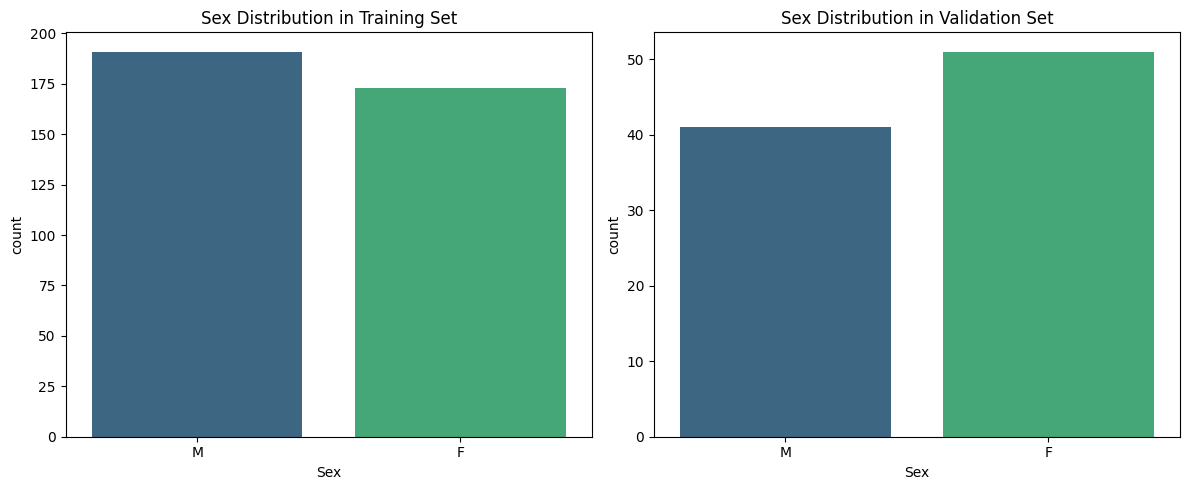

In [29]:
#Explore the metadata (sex) in the training and validation set

#For the training set
sex_freq_train = X_train_metadata['sex_1'].value_counts()
print(f"Frequency of different sexes in the Training Set: {sex_freq_train}")

#For the validation set
sex_freq_val = X_val_metadata['sex_1'].value_counts()
print(f"Frequency of different sexes in the Validation Set: {sex_freq_val}")

sex_names = ['M','F']

fig , axes = plt.subplots(nrows= 1, ncols = 2, figsize=(12,5))

sns.countplot(data=X_train_metadata, x='sex_1', ax=axes[0], palette='viridis')
axes[0].set_title('Sex Distribution in Training Set')
axes[0].set_xticklabels(['M','F'])
axes[0].set_xlabel('Sex')


sns.countplot(data=X_val_metadata, x='sex_1', ax=axes[1], palette='viridis')
axes[1].set_title('Sex Distribution in Validation Set')
axes[1].set_xticklabels(['M','F'])
axes[1].set_xlabel('Sex')

plt.tight_layout()
plt.savefig('../figures/Task1_Figures/Sex_Distribution_Combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
#Save the Dataset Statistics
statistics = {
    'Metric' : ['n (Samples)', 'Age Mean', 'Age Std', 'Age Min', 'Age Max', 'Male Frequency', 'Female Frequency'],
    'Training Set' : [len(y_train), round(y_train.mean(),2), round(y_train.std(), 2), y_train.min(), y_train.max(), sex_freq_train[0], sex_freq_train[1]],
    'Validation Set' : [len(y_val), round(y_val.mean(),2), round(y_val.std(), 2), y_val.min(), y_val.max(), sex_freq_val[0], sex_freq_val[1]]
}

table_statistics = pd.DataFrame(statistics)
table_statistics.to_csv('../data/processed/task1_dataset_statistics.csv', index=False)


<function matplotlib.pyplot.show(close=None, block=None)>

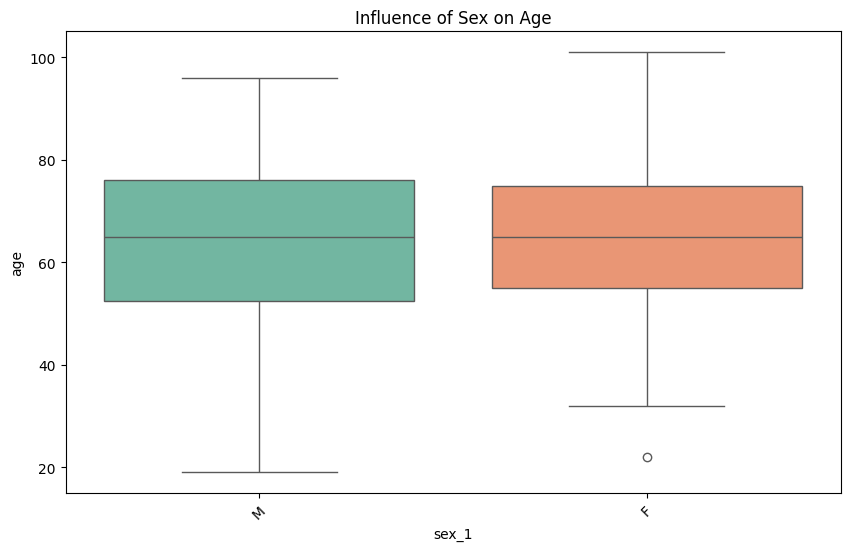

In [31]:
#Explore the metadata of the training set 
plt.figure(figsize=(10,6))
sns.boxplot(data=X_train_metadata, x='sex_1', y=y_train, palette='Set2')
plt.xticks(ticks=[0,1],labels=sex_names, rotation=45)
plt.title(f'Influence of Sex on Age')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

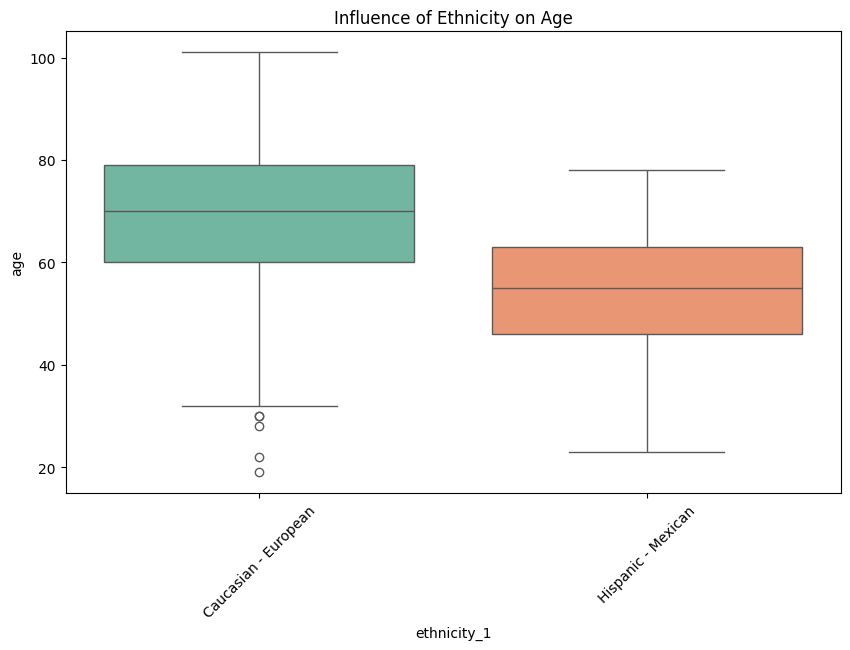

In [32]:
#Explore the metadata of the training set
ethnicity_names = ['Caucasian - European', 'Hispanic - Mexican']

plt.figure(figsize=(10,6))
sns.boxplot(data=X_train_metadata, x='ethnicity_1', y=y_train, palette='Set2')
plt.xticks(ticks=[0,1],labels=ethnicity_names, rotation=45)
plt.title(f'Influence of Ethnicity on Age')
plt.show

In [33]:
#For the numerical variables, calculate the statistics

cpg_stats = X_train_cpg.describe()
cpg_mean = X_train_cpg.mean()

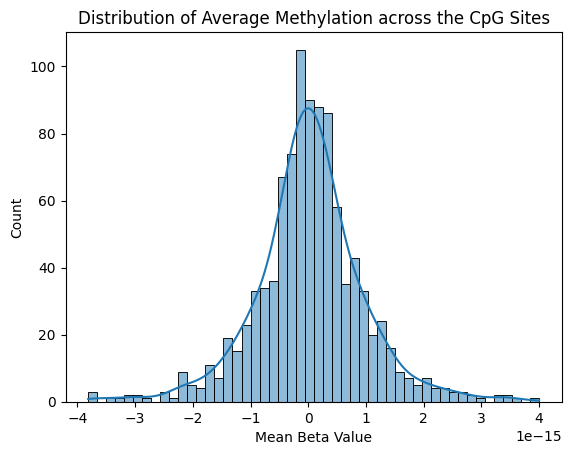

In [34]:
#Plot the distribution of the cpg values in the training set 
sns.histplot(cpg_mean, bins = 50, kde=True)
plt.title("Distribution of Average Methylation across the CpG Sites")
plt.xlabel("Mean Beta Value")
plt.show()

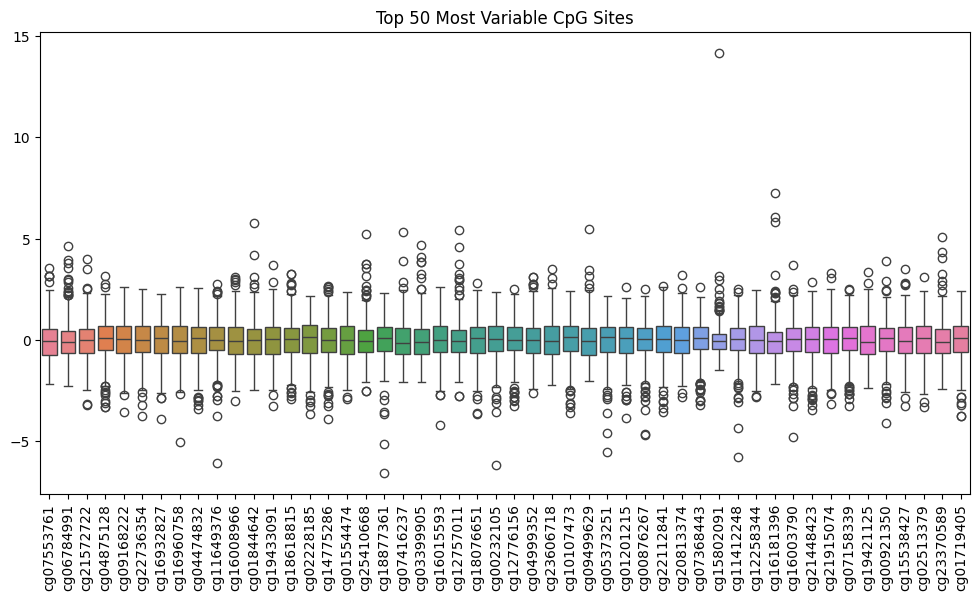

In [35]:
#Calculate the standard deviation for the CpG sites of the training set 
cpg_std = X_train_cpg.std()

#top 50 most variable CpG sites
top50_cpg_std = cpg_std.nlargest(50).index

#Plot those top 50
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train_cpg[top50_cpg_std])
plt.xticks(rotation=90)
plt.title("Top 50 Most Variable CpG Sites")
plt.show()

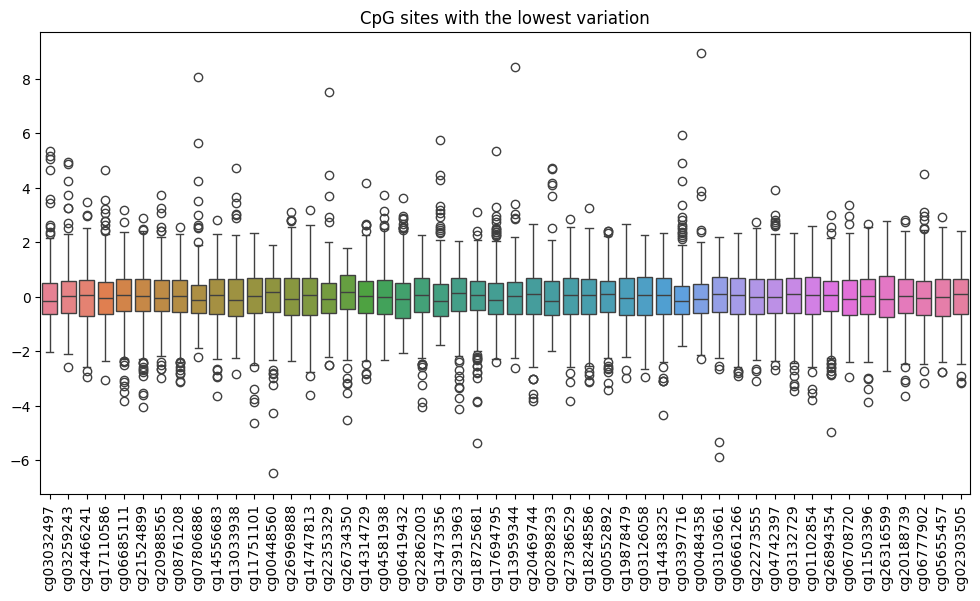

In [36]:
#50 CpG sites with the lower variation
lower50_cpg_std = cpg_std.nsmallest(50).index

#Plot those 50
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train_cpg[lower50_cpg_std])
plt.xticks(rotation=90)
plt.title("CpG sites with the lowest variation")
plt.show()